

# Практического задания №1 «Простой детектор без ML»
Цель: Изучить базовую логику анализа телеметрии спутника ДЗЗ и реализовать алгоритм обнаружения потенциально нештатных ситуаций на основе фиксированных правил.


1. Загрузка библиотек и данных


In [4]:
# @title
# 1. Загрузка библиотек и данных
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Включение отображения графиков прямо в ноутбуке
%matplotlib inline

# Загрузка датасета
df = pd.read_csv('telemetry_dzz_sem1.csv')

# Преобразуем метку времени в формат datetime для удобства построения графиков
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Файл успешно загружен!")

Файл успешно загружен!


# 2. Вывод размерности, первых строк и основных статистик


In [5]:
# @title
# 2. Вывод размерности, первых строк и основных статистик

print("--- 1. Первые 5 строк таблицы ---")
display(df.head())

print("\n--- 2. Размерность датасета (строки, столбцы) ---")
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")

print("\n--- 3. Основная информация о типах данных и пропусках ---")
df.info()

print("\n--- 4. Статистические характеристики (describe) ---")
display(df.describe())

--- 1. Первые 5 строк таблицы ---


,timestamp,temperature,voltage,current,angular_velocity,mode
0,2026-09-07 08:00:00,23.94,28.24,1.44,0.033,standby
1,2026-09-07 08:01:00,24.11,28.13,1.48,0.022,standby
2,2026-09-07 08:02:00,24.23,28.23,1.48,0.039,standby
3,2026-09-07 08:03:00,24.79,28.22,1.41,0.013,standby
4,2026-09-07 08:04:00,24.77,28.29,1.48,0.024,standby



--- 2. Размерность датасета (строки, столбцы) ---
Строк: 720, Столбцов: 6

--- 3. Основная информация о типах данных и пропусках ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         720 non-null    datetime64[ns]
 1   temperature       720 non-null    float64       
 2   voltage           720 non-null    float64       
 3   current           720 non-null    float64       
 4   angular_velocity  720 non-null    float64       
 5   mode              720 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 33.9+ KB

--- 4. Статистические характеристики (describe) ---


,timestamp,temperature,voltage,current,angular_velocity
count,720,720.000000,720.000000,720.000000,720.000000
mean,2026-09-07 13:59:30,29.475694,27.756694,3.288667,0.122862
min,2026-09-07 08:00:00,20.670000,23.090000,1.230000,0.000000
25%,2026-09-07 10:59:45,24.437500,27.510000,1.487500,0.021000
50%,2026-09-07 13:59:30,28.050000,27.965000,3.000000,0.031500
75%,2026-09-07 16:59:15,31.967500,28.200000,5.110000,0.046000
max,2026-09-07 19:59:00,68.230000,28.610000,10.320000,2.431000
std,NaN,7.697992,0.852317,2.012883,0.288402


# Блок 3 (Код в Colab): Этап 3 — Визуализация исходных данных

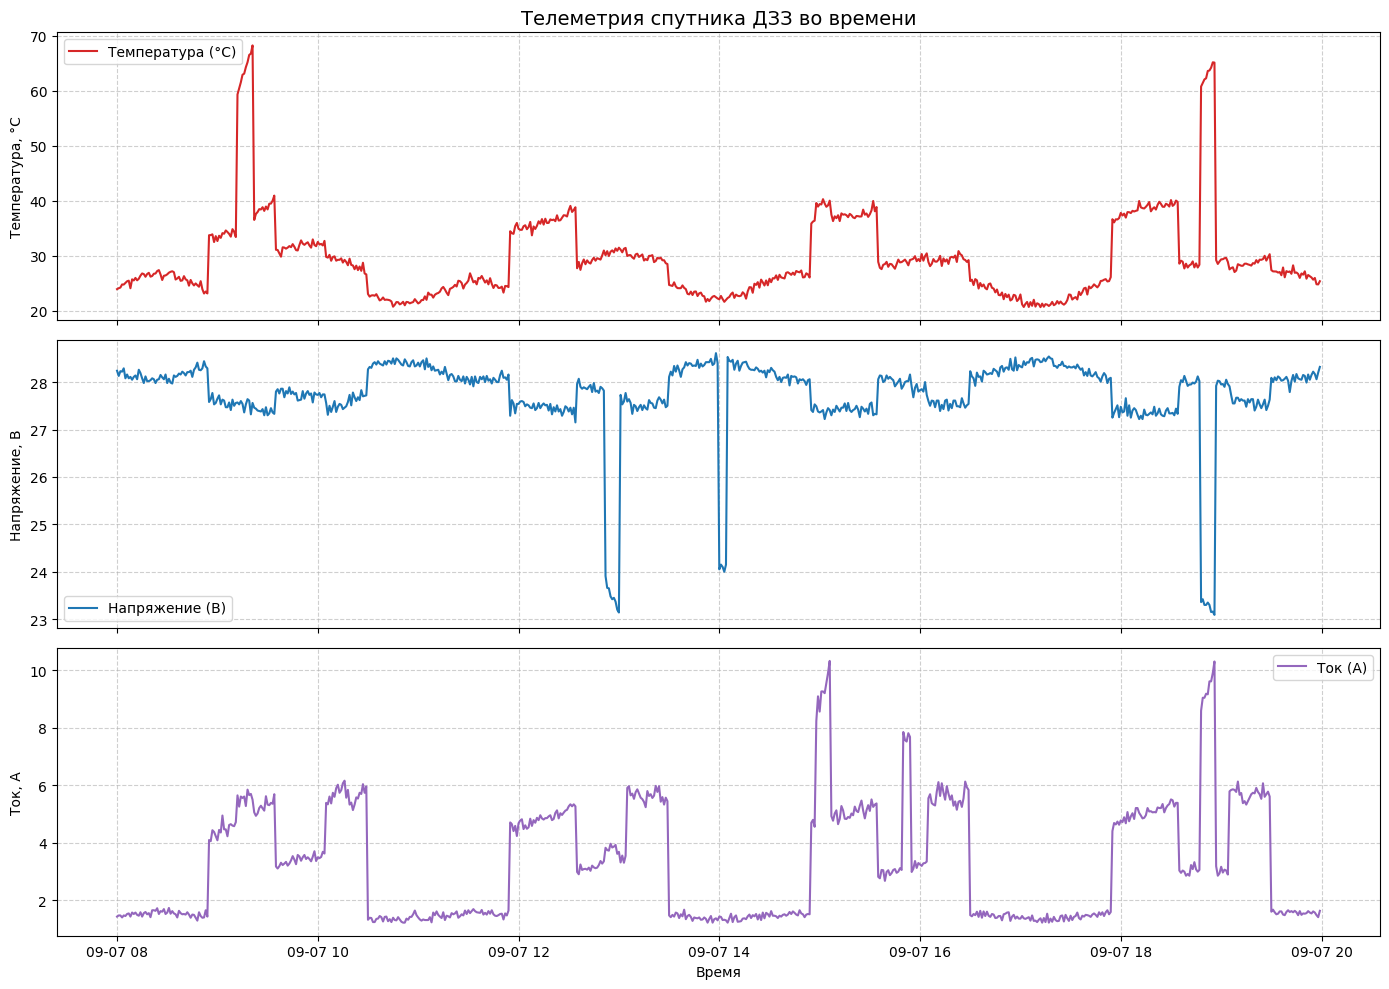

In [6]:
# 3. Графики изменения трех (и более) параметров во времени

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 1. График температуры
axes[0].plot(df['timestamp'], df['temperature'], color='tab:red', label='Температура (°C)')
axes[0].set_ylabel('Температура, °C')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()
axes[0].set_title('Телеметрия спутника ДЗЗ во времени', fontsize=14)

# 2. График напряжения
axes[1].plot(df['timestamp'], df['voltage'], color='tab:blue', label='Напряжение (В)')
axes[1].set_ylabel('Напряжение, В')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# 3. График тока
axes[2].plot(df['timestamp'], df['current'], color='tab:purple', label='Ток (А)')
axes[2].set_ylabel('Ток, А')
axes[2].set_xlabel('Время')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend()

plt.tight_layout()
plt.show()

# Блок 4 (Код в Colab): Этапы 4, 5, 6
— Реализация Чувствительного и Консервативного детектора

In [7]:
# 4, 5, 6. Формулирование правил и создание столбцов аномалий

# --- Правила для Детектора №1 (Чувствительный) ---
# Срабатывает даже при мягких пороговых значениях
rule1_sens = df['temperature'] > 35.0
rule2_sens = df['voltage'] < 27.5
rule3_sens = df['current'] > 5.5
rule4_sens = df['angular_velocity'] > 0.1

df['anomaly_sensitive'] = (rule1_sens | rule2_sens | rule3_sens | rule4_sens).astype(int)


# --- Правила для Детектора №2 (Консервативный) ---
# Срабатывает только при сильных отклонениях от нормы
rule1_cons = df['temperature'] > 50.0
rule2_cons = df['voltage'] < 25.0
rule3_cons = df['current'] > 8.0
rule4_cons = df['angular_velocity'] > 1.0

df['anomaly_conservative'] = (rule1_cons | rule2_cons | rule3_cons | rule4_cons).astype(int)


# Вывод количества найденных аномалий каждым детектором
print("--- РЕЗУЛЬТАТЫ СРАВНЕНИЯ ДЕТЕКТОРОВ ---")
print(f"Детектор №1 (Чувствительный) обнаружил аномалий: {df['anomaly_sensitive'].sum()} записей")
print(f"Детектор №2 (Консервативный) обнаружил аномалий: {df['anomaly_conservative'].sum()} записей")

--- РЕЗУЛЬТАТЫ СРАВНЕНИЯ ДЕТЕКТОРОВ ---
Детектор №1 (Чувствительный) обнаружил аномалий: 277 записей
Детектор №2 (Консервативный) обнаружил аномалий: 52 записей


# Блок 5 (Код в Colab): Этапы 7 и 8
— Поиск аномальных интервалов и нанесение точек на график

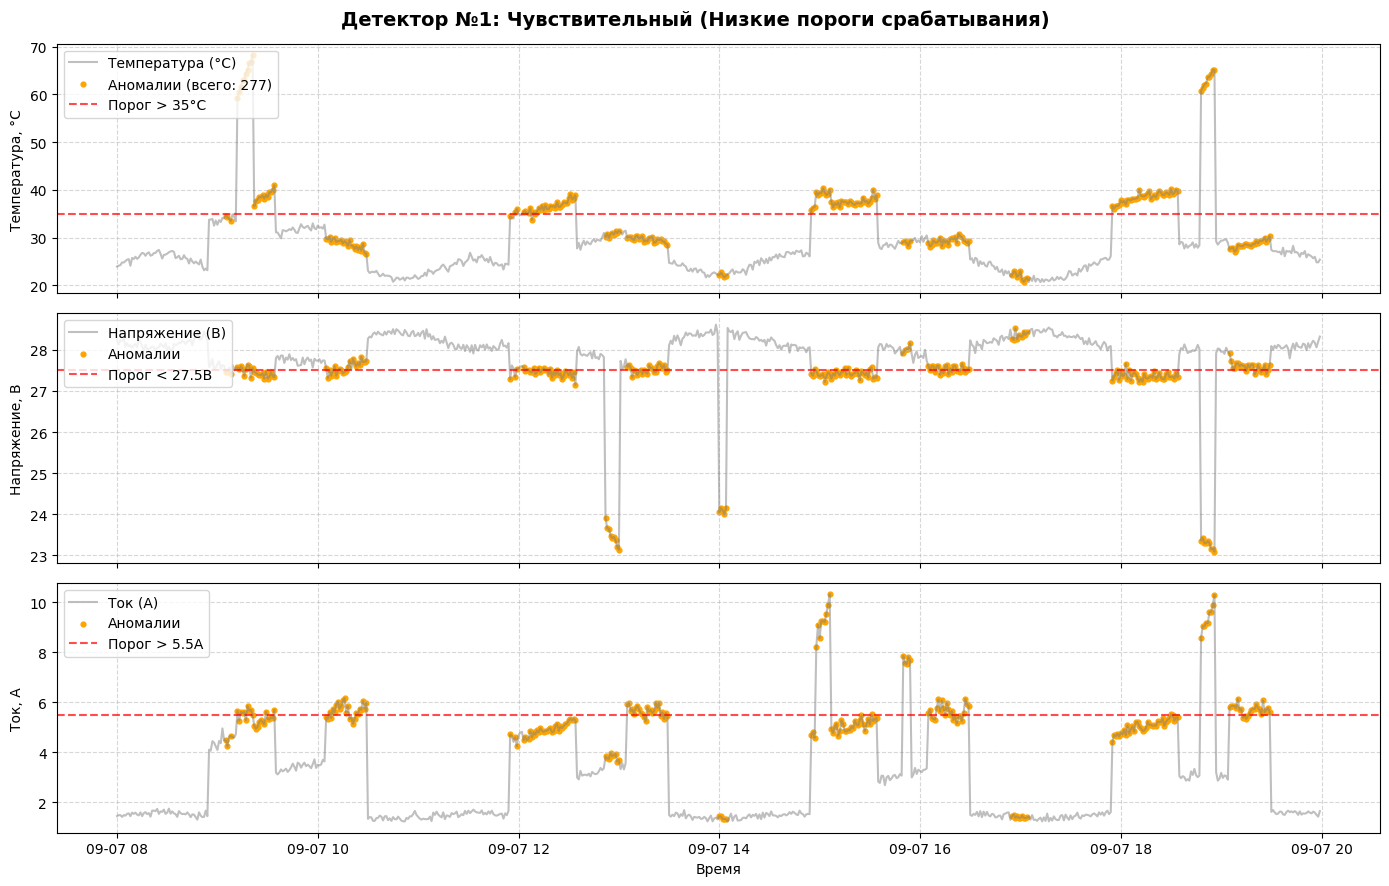

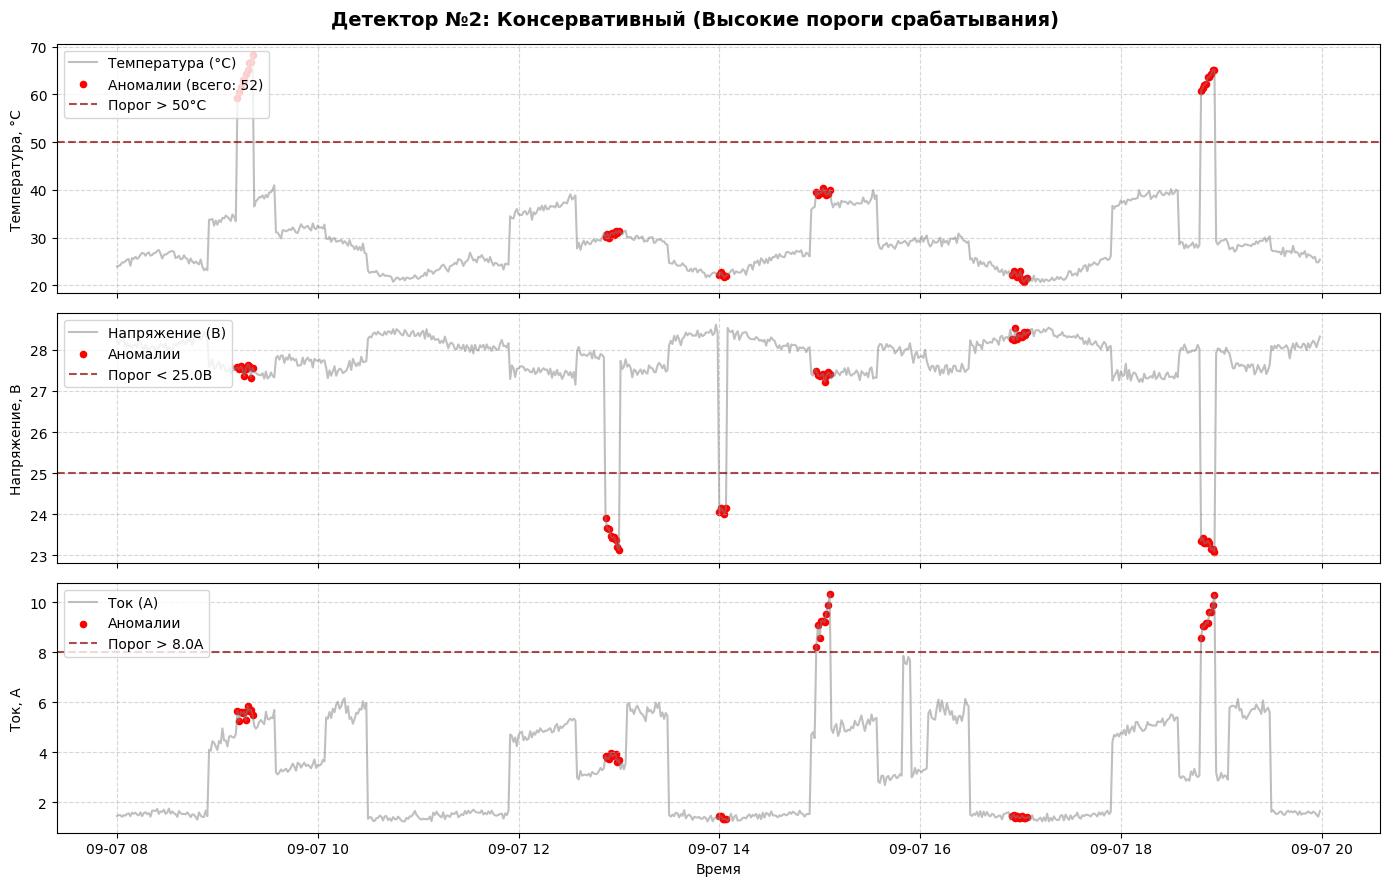

In [9]:
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# ГРАФИК 1: Детектор №1 (Чувствительный)
# -------------------------------------------------------------------------
anom_sens = df[df['anomaly_sensitive'] == 1]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Детектор №1: Чувствительный (Низкие пороги срабатывания)', fontsize=14, fontweight='bold')

# Температура
axes[0].plot(df['timestamp'], df['temperature'], color='gray', alpha=0.5, label='Температура (°C)')
axes[0].scatter(anom_sens['timestamp'], anom_sens['temperature'], color='orange', s=12, label=f'Аномалии (всего: {len(anom_sens)})')
axes[0].axhline(y=35.0, color='red', linestyle='--', alpha=0.7, label='Порог > 35°C')
axes[0].set_ylabel('Температура, °C')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper left')

# Напряжение
axes[1].plot(df['timestamp'], df['voltage'], color='gray', alpha=0.5, label='Напряжение (В)')
axes[1].scatter(anom_sens['timestamp'], anom_sens['voltage'], color='orange', s=12, label='Аномалии')
axes[1].axhline(y=27.5, color='red', linestyle='--', alpha=0.7, label='Порог < 27.5В')
axes[1].set_ylabel('Напряжение, В')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper left')

# Ток
axes[2].plot(df['timestamp'], df['current'], color='gray', alpha=0.5, label='Ток (А)')
axes[2].scatter(anom_sens['timestamp'], anom_sens['current'], color='orange', s=12, label='Аномалии')
axes[2].axhline(y=5.5, color='red', linestyle='--', alpha=0.7, label='Порог > 5.5А')
axes[2].set_ylabel('Ток, А')
axes[2].set_xlabel('Время')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# ГРАФИК 2: Детектор №2 (Консервативный)
# -------------------------------------------------------------------------
anom_cons = df[df['anomaly_conservative'] == 1]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Детектор №2: Консервативный (Высокие пороги срабатывания)', fontsize=14, fontweight='bold')

# Температура
axes[0].plot(df['timestamp'], df['temperature'], color='gray', alpha=0.5, label='Температура (°C)')
axes[0].scatter(anom_cons['timestamp'], anom_cons['temperature'], color='red', s=20, label=f'Аномалии (всего: {len(anom_cons)})')
axes[0].axhline(y=50.0, color='darkred', linestyle='--', alpha=0.7, label='Порог > 50°C')
axes[0].set_ylabel('Температура, °C')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper left')

# Напряжение
axes[1].plot(df['timestamp'], df['voltage'], color='gray', alpha=0.5, label='Напряжение (В)')
axes[1].scatter(anom_cons['timestamp'], anom_cons['voltage'], color='red', s=20, label='Аномалии')
axes[1].axhline(y=25.0, color='darkred', linestyle='--', alpha=0.7, label='Порог < 25.0В')
axes[1].set_ylabel('Напряжение, В')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper left')

# Ток
axes[2].plot(df['timestamp'], df['current'], color='gray', alpha=0.5, label='Ток (А)')
axes[2].scatter(anom_cons['timestamp'], anom_cons['current'], color='red', s=20, label='Аномалии')
axes[2].axhline(y=8.0, color='darkred', linestyle='--', alpha=0.7, label='Порог > 8.0А')
axes[2].set_ylabel('Ток, А')
axes[2].set_xlabel('Время')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()

# Блок 6 (Текст в Colab): Ответы на вопросы для вывода
### 📊 Выводы и сравнение детекторов

### 1. Сравнительная таблица работы алгоритмов

| Тип детектора | Пороговые значения признаков | Количество аномалий | Характеристика работы |
| :--- | :--- | :---: | :--- |
| **Детектор №1 (Чувствительный)** | `temp > 35.0` <br> `voltage < 27.5` <br> `current > 5.5` <br> `ang_vel > 0.1` | **277** | Высокий уровень ложноположительных срабатываний. Ловит штатные рабочие пики нагрузки при съемке. |
| **Детектор №2 (Консервативный)** | `temp > 50.0` <br> `voltage < 25.0` <br> `current > 8.0` <br> `ang_vel > 1.0` | **52** | Фиксирует только критические аварийные всплески, но проникающие мелкие аномалии остаются незамеченными. |

---

## 2. Ответы на вопросы к работе

### 1. Какие параметры оказались наиболее полезными для обнаружения нештатных состояний?
> Наиболее информативными оказались **Температура (`temperature`)** и **Ток (`current`)**.
> - При возрастании нагрузки на аппаратуру ток резко увеличивается, вызывая последующий нагрев элемента.
> - **Напряжение (`voltage`)** также полезно, так как при росте тока наблюдается соразмерное проседание напряжения бортовой сети.

---

### 2. Как выбор порогов влияет на количество обнаруженных аномалий?
> - **Низкие пороги (Чувствительный детектор):** Приводят к избыточным срабатываниям (277 точек из 720). В список аномалий попадают штатные рабочие режимы спутника (например, режим съёмки `imaging`).
> - **Высокие пороги (Консервативный детектор):** Сокращают количество аномалий до 52, фиксируя только явные критические сбои, но упускают развивающиеся мелкие неисправности.

---

### 3. Может ли одно и то же значение температуры быть нормальным в одном режиме работы и ненормальным в другом?
> **Да, может.**
> - Например, температура **$38^\circ\text{C}$** вполне естественна во время работы целевой аппаратуры в режиме **`imaging`** (съёмка Earth).
> - Однако для режима ожидания **`standby`**, когда большинство систем спутника отключены или работают на минимуме, такая температура свидетельствует о нештатном нагреве или коротком замыкании.

---

### 4. Какие проблемы возникают при использовании большого количества жестких правил?
> 1. **Отсутствие учета контекста:** Правила с фиксированным порогом одинаково применяются ко всем режимам работы (`mode`).
> 2. **Сложность поддержки:** При увеличении числа датчиков вручную подбирать и корректировать пороги становится невозможно.
> 3. **Ложные срабатывания или пропуски:** Жесткая граница не учитывает динамику изменений во времени (например, плавный нагрев vs резкий скачок).

---

### 5. Чем такой подход отличается от машинного обучения?
> - **Подход на правилах (Rule-based):** Требует от человека вручную сформулировать условия (`if/else`) и подбирать числовые значения порогов на основе опыта.
> - **Машинное обучение (ML):** Алгоритм самостоятельно анализирует исторические данные, выявляет сложные зависимости между несколькими параметрами и автоматизирует определение гибких норм для каждого режима без участия человека.